# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering (Estelle's feature + my own features)
4. Drop redundant columns
5. Check usefulness against churn
6. Save

---

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---
## 2. Load data

In [3]:
df = pd.read_csv('./clean_data_after_eda.csv')
for c in ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']:
    df[c] = pd.to_datetime(df[c], format='%Y-%m-%d')
print(df.shape)
df.head(3)

(14606, 44)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


In [6]:
price_df = pd.read_csv(r"C:\Users\Dell\Downloads\price_data (1).csv")
price_df['price_date'] = pd.to_datetime(price_df['price_date'], format='%Y-%m-%d')
print(price_df.shape)
price_df.head()

(193002, 8)


,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


---
## 3. Feature engineering

### 3.1 Estelle's feature: difference between off-peak prices in December and preceding January

In [7]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


### 3.2 Building on it: price features for all 6 price columns
The Dec-Jan difference only uses two off-peak columns and only two months. Price sensitivity can also show up in peak/mid-peak prices, in the level of the price, its volatility, and the biggest jump between two months. I create all of these per client.

In [8]:
price_cols = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
              'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']
p = price_df.sort_values(['id', 'price_date'])

# Dec - Jan difference for every price column (not just off-peak)
first = p.groupby('id')[price_cols].first()
last = p.groupby('id')[price_cols].last()
dec_jan = (last - first).add_suffix('_diff_dec_jan')

# Level and volatility of the price over the year
mean_p = p.groupby('id')[price_cols].mean().add_suffix('_mean')
std_p = p.groupby('id')[price_cols].std().fillna(0).add_suffix('_std')

# Largest month-to-month jump (max absolute change between consecutive months)
p_diff = p.groupby('id')[price_cols].diff().abs()
p_diff['id'] = p['id']
max_jump = p_diff.groupby('id')[price_cols].max().fillna(0).add_suffix('_max_jump')

# Change over the last 6 months (Dec vs Jul) - most recent price movement
p6 = p[p['price_date'] >= '2015-07-01']
last6 = (p6.groupby('id')[price_cols].last() - p6.groupby('id')[price_cols].first()).add_suffix('_diff_last6m')

price_features = pd.concat([dec_jan, mean_p, std_p, max_jump, last6], axis=1).reset_index()
price_features.shape

(16096, 31)

In [9]:
# Combined price features: total energy price, total power price, and relative change
price_features['mean_energy_price'] = price_features[['price_off_peak_var_mean', 'price_peak_var_mean', 'price_mid_peak_var_mean']].sum(axis=1)
price_features['mean_power_price'] = price_features[['price_off_peak_fix_mean', 'price_peak_fix_mean', 'price_mid_peak_fix_mean']].sum(axis=1)
# Relative (%) change of the off-peak energy price Dec vs Jan
first_offpeak = first['price_off_peak_var'].reset_index(drop=True)
price_features['offpeak_energy_pct_change'] = price_features['price_off_peak_var_diff_dec_jan'] / first_offpeak.replace(0, np.nan)
price_features['offpeak_energy_pct_change'] = price_features['offpeak_energy_pct_change'].fillna(0)
price_features.head(3)

,id,price_off_peak_var_diff_dec_jan,price_peak_var_diff_dec_jan,price_mid_peak_var_diff_dec_jan,price_off_peak_fix_diff_dec_jan,price_peak_fix_diff_dec_jan,price_mid_peak_fix_diff_dec_jan,price_off_peak_var_mean,price_peak_var_mean,price_mid_peak_var_mean,...,price_mid_peak_fix_max_jump,price_off_peak_var_diff_last6m,price_peak_var_diff_last6m,price_mid_peak_var_diff_last6m,price_off_peak_fix_diff_last6m,price_peak_fix_diff_last6m,price_mid_peak_fix_diff_last6m,mean_energy_price,mean_power_price,offpeak_energy_pct_change
0,0002203ffbb812588b632b9e628cc38d,-0.006192,-0.002302,0.003487,0.162916,0.097749,0.065166,0.124338,0.103794,0.07316,...,0.065166,-0.008161,-0.004169,-0.000054,0.0,0.0,0.0,0.301293,81.403465,-0.049105
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.000000,0.000000,0.177779,0.000000,0.000000,0.146426,0.000000,0.00000,...,0.000000,-0.004462,0.000000,0.000000,0.0,0.0,0.0,0.146426,44.385450,-0.027721
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,0.000000,0.000000,1.500000,0.000000,0.000000,0.181558,0.000000,0.00000,...,0.000000,-0.004462,0.000000,0.000000,0.0,0.0,0.0,0.181558,45.319710,0.334421


### 3.3 Date features
Raw dates are not directly useful. I convert them to durations (in months) relative to a fixed reference date (1 Jan 2016, the start of the prediction window) and also extract the month and year of activation.

In [10]:
ref_date = pd.to_datetime('2016-01-01')

def months_between(a, b):
    return (a - b).dt.days / 30.44

df['months_activ'] = months_between(ref_date, df['date_activ'])           # how long the client has been with PowerCo
df['months_to_end'] = months_between(df['date_end'], ref_date)            # time left on contract
df['months_to_renewal'] = months_between(df['date_renewal'], ref_date)    # time until next renewal
df['months_since_modif'] = months_between(ref_date, df['date_modif_prod'])# time since last product change
df['contract_length_months'] = months_between(df['date_end'], df['date_activ'])
df['activ_month'] = df['date_activ'].dt.month
df['activ_year'] = df['date_activ'].dt.year
df['end_month'] = df['date_end'].dt.month
df['renewal_month'] = df['date_renewal'].dt.month
df[['months_activ', 'months_to_end', 'months_to_renewal', 'months_since_modif', 'contract_length_months']].describe().T

,count,mean,std,min,25%,50%,75%,max
months_activ,14606.0,59.089048,19.359984,15.998686,44.415243,57.950066,71.517740,151.773982
months_to_end,14606.0,6.861596,3.512931,0.886991,3.851840,6.997372,9.986859,17.378449
months_to_renewal,14606.0,-5.378089,3.889980,-30.190539,-8.508541,-5.190539,-2.102497,0.886991
months_since_modif,14606.0,35.922462,30.304631,-0.919842,6.537451,30.420499,64.651774,151.773982
contract_length_months,14606.0,65.950643,19.871079,24.014455,47.996058,60.068988,77.299606,157.522996


### 3.4 Combined / ratio features
Combining columns can express things a single column cannot, e.g. how big the discount is compared with consumption, or how much margin the client generates per unit of power.

In [11]:
eps = 1e-6
df['margin_per_power'] = df['net_margin'] / (df['pow_max'] + eps)
df['cons_per_power'] = df['cons_12m'] / (df['pow_max'] + eps)
df['last_month_share_of_12m'] = df['cons_last_month'] / (df['cons_12m'] + eps)   # is usage falling/rising recently?
df['forecast_vs_actual_cons'] = df['forecast_cons_12m'] / (df['cons_12m'] + eps)  # does the client expect to use less?
df['imp_cons_share'] = df['imp_cons'] / (df['cons_12m'] + eps)
df['total_cons'] = df['cons_12m'] + df['cons_gas_12m']
df['discount_share'] = df['forecast_discount_energy'] / (df['forecast_price_energy_off_peak'] + eps)
df['margin_per_product'] = df['net_margin'] / df['nb_prod_act'].replace(0, np.nan)
df['margin_per_product'] = df['margin_per_product'].fillna(0)

# cap the huge ratios caused by very small denominators
for c in ['margin_per_power', 'cons_per_power', 'last_month_share_of_12m', 'forecast_vs_actual_cons', 'imp_cons_share', 'discount_share']:
    df[c] = df[c].clip(upper=df[c].quantile(0.99))
df[['margin_per_power', 'cons_per_power', 'last_month_share_of_12m', 'forecast_vs_actual_cons', 'total_cons']].describe().T

,count,mean,std,min,25%,50%,75%,max
margin_per_power,14606.0,10.356593,9.733429,0.0,3.618913,7.458333,13.686367,5.116889e+01
cons_per_power,14606.0,8831.427300,29911.851026,0.0,401.557436,895.484432,2165.126825,2.058212e+05
last_month_share_of_12m,14606.0,0.074955,0.076338,0.0,0.000000,0.072089,0.112230,3.385045e-01
forecast_vs_actual_cons,14606.0,0.093031,0.054300,0.0,0.043243,0.102346,0.147488,1.897813e-01
total_cons,14606.0,187312.661577,668376.889868,0.0,6222.250000,16339.500000,50821.750000,6.799539e+06


### 3.5 Skewed variables: log transform
Consumption, forecast and margin columns are strongly right-skewed (seen in the EDA). A `log10(x + 1)` transform makes them closer to normal and reduces the influence of outliers.

In [12]:
skewed = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year',
          'forecast_meter_rent_12m', 'imp_cons', 'net_margin', 'margin_gross_pow_ele', 'margin_net_pow_ele',
          'pow_max', 'total_cons']
print(df[skewed].skew().round(2))
for c in skewed:
    df[c + '_log'] = np.log10(df[c].clip(lower=0) + 1)
print('\nAfter log:'); print(df[[c + '_log' for c in skewed]].skew().round(2))

cons_12m                    6.00
cons_gas_12m                9.60
cons_last_month             6.39
forecast_cons_12m           7.16
forecast_cons_year         16.59
forecast_meter_rent_12m     1.51
imp_cons                   13.20
net_margin                 36.57
margin_gross_pow_ele        4.47
margin_net_pow_ele          4.47
pow_max                     5.79
total_cons                  5.92
dtype: float64

After log:
cons_12m_log                  -0.38
cons_gas_12m_log               1.88
cons_last_month_log           -0.19
forecast_cons_12m_log         -2.03
forecast_cons_year_log        -0.12
forecast_meter_rent_12m_log   -0.60
imp_cons_log                   0.01
net_margin_log                -0.97
margin_gross_pow_ele_log      -1.31
margin_net_pow_ele_log        -1.31
pow_max_log                    1.80
total_cons_log                -0.31
dtype: float64


### 3.6 Categorical variables
`has_gas` is true/false and `channel_sales` / `origin_up` are hashed categories. I map `has_gas` to 0/1 and one-hot encode the other two.

In [13]:
df['has_gas'] = df['has_gas'].replace({'t': 1, 'f': 0}).astype(int)
df = pd.get_dummies(df, columns=['channel_sales', 'origin_up'], prefix=['channel', 'origin'], dtype=int)
df.filter(like='channel_').columns.tolist(), df.filter(like='origin_').columns.tolist()

C:\Users\Dell\AppData\Local\Temp\ipykernel_6436\664612121.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['has_gas'] = df['has_gas'].replace({'t': 1, 'f': 0}).astype(int)


(['channel_MISSING',
  'channel_epumfxlbckeskwekxbiuasklxalciiuu',
  'channel_ewpakwlliwisiwduibdlfmalxowmwpci',
  'channel_fixdbufsefwooaasfcxdxadsiekoceaa',
  'channel_foosdfpfkusacimwkcsosbicdxkicaua',
  'channel_lmkebamcaaclubfxadlmueccxoimlema',
  'channel_sddiedcslfslkckwlfkdpoeeailfpeds',
  'channel_usilxuppasemubllopkaafesmlibmsdf'],
 ['origin_MISSING',
  'origin_ewxeelcelemmiwuafmddpobolfuxioce',
  'origin_kamkkxfxxuwbdslkwifmmcsiusiuosws',
  'origin_ldkssxwpmemidmecebumciepifcamkci',
  'origin_lxidpiddsbxsbosboudacockeimpuepw',
  'origin_usapbepcfoloekilkwsdiboslwaxobdp'])

### 3.7 Merge the price features with the client data
Both datasets share the client `id`, so I join on it (left join keeps all 14,606 clients).

In [14]:
df = df.merge(diff, on='id', how='left').merge(price_features, on='id', how='left')
print(df.shape)
print('Missing values after merge:', df.isna().sum().sum())

(14606, 120)
Missing values after merge: 0


---
## 4. Remove columns
Columns are dropped when they are (a) raw dates (replaced by duration features), (b) identical or almost identical to another column (correlation above 0.98), or (c) the original skewed version of a column that now has a log version. Correlated pairs are found programmatically:

In [15]:
num = df.drop(columns=['id', 'churn']).select_dtypes('number')
corr = num.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [c for c in upper.columns if (upper[c] > 0.98).any()]
print(len(high_corr), 'columns with correlation > 0.98 with another column')
high_corr

23 columns with correlation > 0.98 with another column


['margin_net_pow_ele',
 'var_year_price_off_peak',
 'var_year_price_peak',
 'var_year_price_mid_peak',
 'var_6m_price_off_peak',
 'var_6m_price_peak',
 'var_6m_price_mid_peak',
 'months_activ',
 'contract_length_months',
 'activ_year',
 'discount_share',
 'imp_cons_log',
 'margin_net_pow_ele_log',
 'price_off_peak_var_diff_dec_jan',
 'price_off_peak_fix_diff_dec_jan',
 'price_mid_peak_fix_diff_dec_jan',
 'price_peak_var_mean',
 'price_peak_fix_mean',
 'price_mid_peak_fix_mean',
 'price_mid_peak_fix_std',
 'price_off_peak_fix_max_jump',
 'price_mid_peak_fix_max_jump',
 'price_mid_peak_fix_diff_last6m']

In [16]:
# keep the log version of the skewed columns, drop the raw ones and the near-duplicates of price columns
raw_dates = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
drop_cols = set(raw_dates) | set(skewed) | {c for c in high_corr if not c.endswith('_log')}
drop_cols |= {'margin_gross_pow_ele_log'}   # near-identical to margin_net_pow_ele_log
df_final = df.drop(columns=[c for c in drop_cols if c in df.columns])
print('Before:', df.shape, ' After:', df_final.shape)

Before: (14606, 120)  After: (14606, 83)


---
## 5. Quick check: are the new features related to churn?
This is only a first look (correlation with churn); the real test comes in the modelling step.

In [17]:
new_feats = [c for c in df_final.columns if c not in ['id', 'churn'] and df_final[c].dtype != object]
cc = df_final[new_feats + ['churn']].corr()['churn'].drop('churn')
top = cc.reindex(cc.abs().sort_values(ascending=False).index).head(15)
top

origin_lxidpiddsbxsbosboudacockeimpuepw     0.094131
origin_kamkkxfxxuwbdslkwifmmcsiusiuosws    -0.080766
channel_foosdfpfkusacimwkcsosbicdxkicaua    0.075964
num_years_antig                            -0.074140
margin_net_pow_ele_log                      0.072531
channel_lmkebamcaaclubfxadlmueccxoimlema   -0.052946
mean_power_price                            0.052386
months_since_modif                         -0.052072
cons_per_power                             -0.046818
price_mid_peak_var_mean                     0.046544
channel_MISSING                            -0.041840
mean_energy_price                           0.040354
forecast_meter_rent_12m_log                 0.038964
price_off_peak_var_std                      0.037397
pow_max_log                                 0.034776
Name: churn, dtype: float64

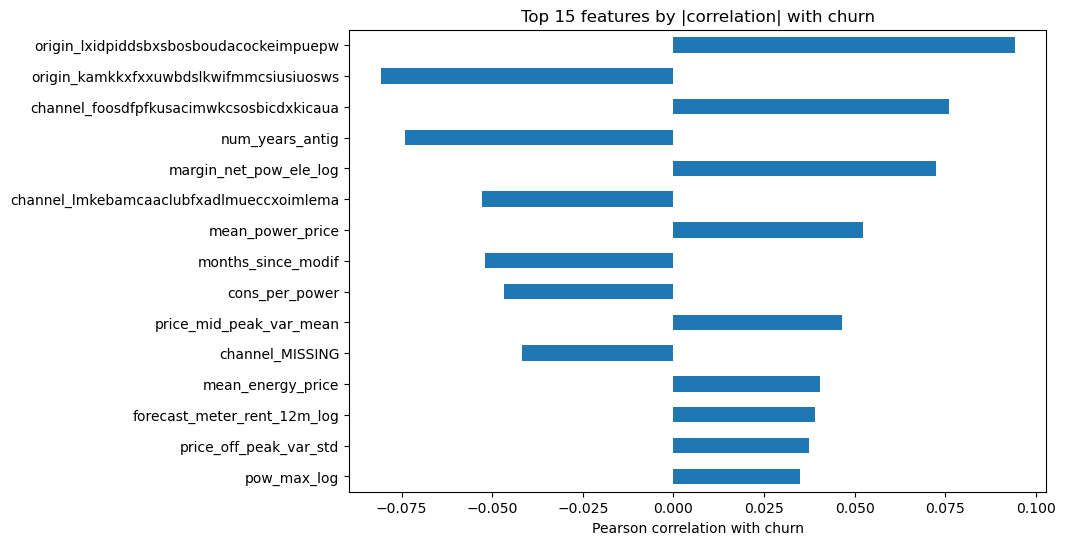

In [18]:
top[::-1].plot(kind='barh', figsize=(9, 6), title='Top 15 features by |correlation| with churn')
plt.xlabel('Pearson correlation with churn')
plt.show()

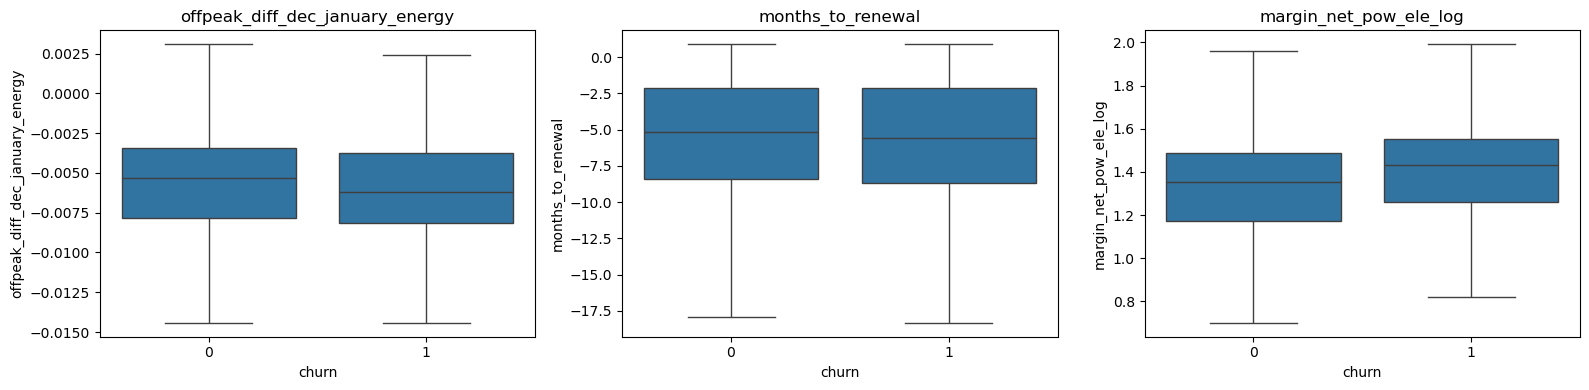

In [19]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axs, ['offpeak_diff_dec_january_energy', 'months_to_renewal', 'margin_net_pow_ele_log']):
    sns.boxplot(x='churn', y=col, data=df_final, ax=ax, showfliers=False)
    ax.set_title(col)
plt.tight_layout()

**Notes**
- Correlations with churn are all small (typical for a churn problem with ~10% positive class), so no single feature is decisive. Price-change features are not obviously dominant compared with contract/margin features, which is exactly what the model in the next step should test.
- The dataset is still imbalanced (~9.7% churn); this will need attention in modelling.

---
## 6. Save the result

In [20]:
df_final.to_csv('data_for_predictions.csv', index=False)
print(df_final.shape)
df_final.head(3)

(14606, 83)


,id,forecast_discount_energy,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,nb_prod_act,num_years_antig,var_year_price_off_peak_var,var_year_price_peak_var,...,price_mid_peak_var_max_jump,price_peak_fix_max_jump,price_off_peak_var_diff_last6m,price_peak_var_diff_last6m,price_mid_peak_var_diff_last6m,price_off_peak_fix_diff_last6m,price_peak_fix_diff_last6m,mean_energy_price,mean_power_price,offpeak_energy_pct_change
0,24011ae4ebbe3035111d65fa7c15bc57,0.0,0.114481,0.098142,40.606701,1,2,3,0.000061,2.627605e-05,...,0.073819,24.43733,0.020393,-0.018480,-0.073873,3.538045,-24.43733,0.292067,78.195616,0.159213
1,d29c2c54acc38ff3c0614d0a653813dd,0.0,0.145711,0.000000,44.311378,0,1,6,0.000005,6.089453e-04,...,0.000000,0.00000,-0.003767,0.000000,0.000000,0.177780,0.00000,0.156732,44.311375,-0.024887
2,764c75f661154dac3a6c254cd082ea7d,0.0,0.165794,0.087899,44.311378,0,1,6,0.000006,2.558511e-07,...,0.000000,0.00000,-0.004628,-0.000753,0.000000,0.000000,0.00000,0.258933,44.385450,-0.027077
